# Churn SaaS — pipeline de données

Estimer la probabilité de résiliation d'un client à l'échéance, à partir de
`docs/churn_saas_complet.csv` (5035 lignes, 28 % de churn).

**Prérequis** : `docker compose up -d` — PostgreSQL sur le port 5432, pgAdmin sur
http://localhost:5050.

## 🥉🥈🥇 Ingestion complète

Lance les trois couches à la suite : `docs/*.csv` → 🥉 bronze → 🥈 silver →
🥇 gold. Chaque couche est intégralement rechargée, l'exécution est donc
rejouable sans créer de doublons.

In [ ]:
from ml_churn.ingestion.scripts.ingest_all import ingest_all

lignes_ingestion = ingest_all()

## 1. Exploration des données brutes

Deux types de graphiques construits directement sur le CSV, avant toute
ingestion. Les valeurs sont normalisées à la volée — le CSV mélange les casses
(`TPE`, `tpe`, `" TPE "`) et les unités (`20.0%`, `3.1 h`, `280.62 €`).

**Histogrammes** — répartition des clients par secteur, pays, taille
d'entreprise et plan, puis distribution des variables d'usage (ancienneté,
CSAT, délai de réponse du support, revenu mensuel…).

**Boîtes à moustaches** — complémentaires : là où l'histogramme montre la forme
de la distribution, le boxplot isole individuellement chaque point au-delà de
1,5 × IQR, même s'il n'y en a qu'un sur 5000. Les variables très asymétriques
sont tracées en échelle logarithmique ; en linéaire, le critère IQR classe
toute la traîne en valeurs extrêmes et écrase la boîte.

Les PNG sont exportés dans `src/visualization/graphs/<type>/<préfixe>_<donnée>.png`.

In [ ]:
import sys

sys.path.insert(0, "src")  # src/visualization n'est pas un package installe
from visualization.scripts.plot_all import plot_all

graphiques = plot_all()

## 🥉 2. Ingestion — couche bronze

Les trois CSV de `docs/` sont copiés **tels quels** dans le schéma `bronze` :
toutes les colonnes métier en `TEXT`, aucune conversion ni nettoyage. Chaque ligne
conserve son origine (`_source_file`, `_source_line`, `_ingested_at`).

Les tables sont vidées puis rechargées : relancer la cellule ne crée pas de
doublons. Le log compare les lignes lues dans le CSV à celles réellement insérées
en base, et signale tout écart.

In [ ]:
from ml_churn.ingestion.scripts.ingest_bronze import ingest_bronze

lignes_bronze = ingest_bronze()

## 🥈 3. Ingestion — couche silver

`bronze.churn_saas_complet_bronze` → `silver.churn_saas_silver`, en onze actions
successives :

1. **Déduplication** sur `client_id`
2. **Standardisation** de huit colonnes : dates ramenées au format `AAAA-MM-JJ`,
   pays en codes ISO, plans en `PRO`/`BUS`/`STR`/`ENT`, casse et espaces harmonisés
3. **Règles métier** : toute ligne hors bornes est supprimée
4. **Typage** : `date`, `integer` et `numeric` selon la colonne

In [ ]:
from ml_churn.ingestion.scripts.ingest_silver import ingest_silver

lignes_silver = ingest_silver()

## 🥇 4. Ingestion — couche gold

`silver` → `gold`, pour les deux tables : `catalogue_gold` et
`churn_saas_gold`. Les tables reprennent **la structure de silver à
l'identique** (mêmes colonnes, mêmes types) — les définitions sont partagées
via les mixins de `models/colonnes.py`, il n'y a donc pas deux schémas à
maintenir.

Gold est la couche stable sur laquelle s'appuient l'analyse et la
modélisation, sans dépendre des retraitements successifs de silver.

In [ ]:
from ml_churn.ingestion.scripts.ingest_gold import ingest_gold

lignes_gold = ingest_gold()

## 5. Déséquilibre de la cible

Effectifs de chaque valeur de `churn` et taux de résiliation, lus dans
`gold.churn_saas_gold`. Le code est dans `src/ml_churn/training/`.

Ce déséquilibre conditionne le choix des métriques : un modèle qui prédirait
« personne ne résilie » aurait déjà une exactitude égale à la part de clients
actifs.

In [ ]:
from ml_churn.training.classification.analyze_target import analyze_target

repartition_cible = analyze_target()

## 6. Classification — baseline (régression logistique)

**Recherche du seuil.** Les 11 seuils de 0,0 à 1,0 (pas de 0,1) testés sur le modele pour évaluer lequel correspond le plus à notre besoin

Explication des features avec SHAP :

Pour explorer les runs et la matrice de confusion enregistrée :

| # | Feature | Hypothétisé | Fortes valeurs | Faibles valeurs |
|---|---------|:-----------:|:--------------:|:---------------:|
| 1 | nb_integrations | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 2 | anciennete_mois | | ⬇️⬇️⬇️ | ⬆️⬆️⬆️ |
| 3 | derniere_connexion_jours | | ⬆️⬆️⬆️ | ⬇️⬇️ |
| 4 | tickets_support_90j | ✅ | ⬆️⬆️⬆️ | ⬇️⬇️⬇️ |
| 5 | csat | | ⬇️⬇️ | ⬆️⬆️ |
| 6 | retards_paiement_12m | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 7 | taux_adoption_pct | | ⬇️⬇️ | ⬆️⬆️ |
| 8 | delai_reponse_support_h | ✅ | ⬆️⬆️ | ⬇️⬇️ |
| 9 | plan_str | | ⬆️⬆️ | ⬇️ |
| 10 | revenu_mensuel_recurrent_eur | | ⬆️⬆️ | ⬇️ |
| 11 | utilisateurs_actifs | ✅ | ⬇️⬇️ | ⬆️ |
| 12 | fonctionnalites_utilisees | ✅ | ⬇️⬇️ | ⬆️ |
| 13 | plan_ent | | ⬇️⬇️⬇️ | ⬆️ |
| 14 | couleur_theme_interface_v | | ⬇️⬇️ | ⬆️ |
| 15 | taille_entreprise_pme | ✅ | ⬇️ | ⬆️ |
| 16 | heures_usage_30j | | ⬇️ | ⬆️ |
| 17 | niveau_anciennete_ancien | | ⬆️ | ⬇️ |
| 18 | secteur_fi | | ⬇️⬇️ | ⬆️ |
| 19 | taux_fonctionnalites | | ⬆️ | ⬇️ |
| 20 | niveau_anciennete_recent | | ⬇️⬇️ | ⬆️ |

```bash
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

In [ ]:
from ml_churn.training.classification.baseline.classification_baseline_tuning import (
    tune_baseline_threshold,
)

resultat_tuning = tune_baseline_threshold()

**Entraînement et sauvegarde.** Le modèle est évalué au seuil retenu, puis
enregistré dans `artifacts/baseline/<date>/` avec ses métadonnées et les trois
extraits gold (train / validation / test). Remplace `SEUIL` par une valeur fixe
pour comparer les arbitrages : un seuil bas détecte plus de churners au prix de
fausses alertes, un seuil haut fait l'inverse.

Le seuil retenu est de 0.5 (recall = 0.8 / FPR = 0.19)

**Explication (SHAP).** Deux lectures des mêmes contributions, mesurées sur le
jeu de test :

| Graphique | Ce qu'il montre |
|---|---|
| **Bar plot** | Moyenne des \|SHAP\| par feature : le classement d'importance, sans le sens de l'effet |
| **Summary plot** | Un point par client : position = effet sur la prédiction (droite = pousse vers le churn), couleur = valeur de la feature (rouge = élevée) |

[SEUIL] 0.50
[DONNEES] : 5000 clients, 64 features
  exclues : client_id, code_datacenter, couleur_theme_interface, date_souscription, groupe_experimentation, jour_souscription, niveau_anciennete, pays, plan, polarite_csm, sante_compte_fin_periode, secteur, taille_entreprise, valeur_vie_client_eur
  train 3000 / validation 1000 / test 1000  (churn 28.00% dans le test)

[PERFORMANCE] sur le jeu de test
  accuracy              0.8080   (TP+TN) / (TP+TN+FP+FN)
  recall                0.8000   TP / (TP+FN)
  false_positive_rate   0.1889   FP / (FP+TN)
  precision             0.6222   TP / (TP+FP)
  auc                   0.8773   aire sous la courbe ROC (independante du seuil)

[MATRICE DE CONFUSION]
                       predit reste       predit churn
  reel reste               TN = 584           FP = 136
  reel churn                FN = 56           TP = 224

  TP = 224   churners detectes
  FN = 56    churners manques
  FP = 136   fausses alertes
  TN = 584   clients fideles correcteme

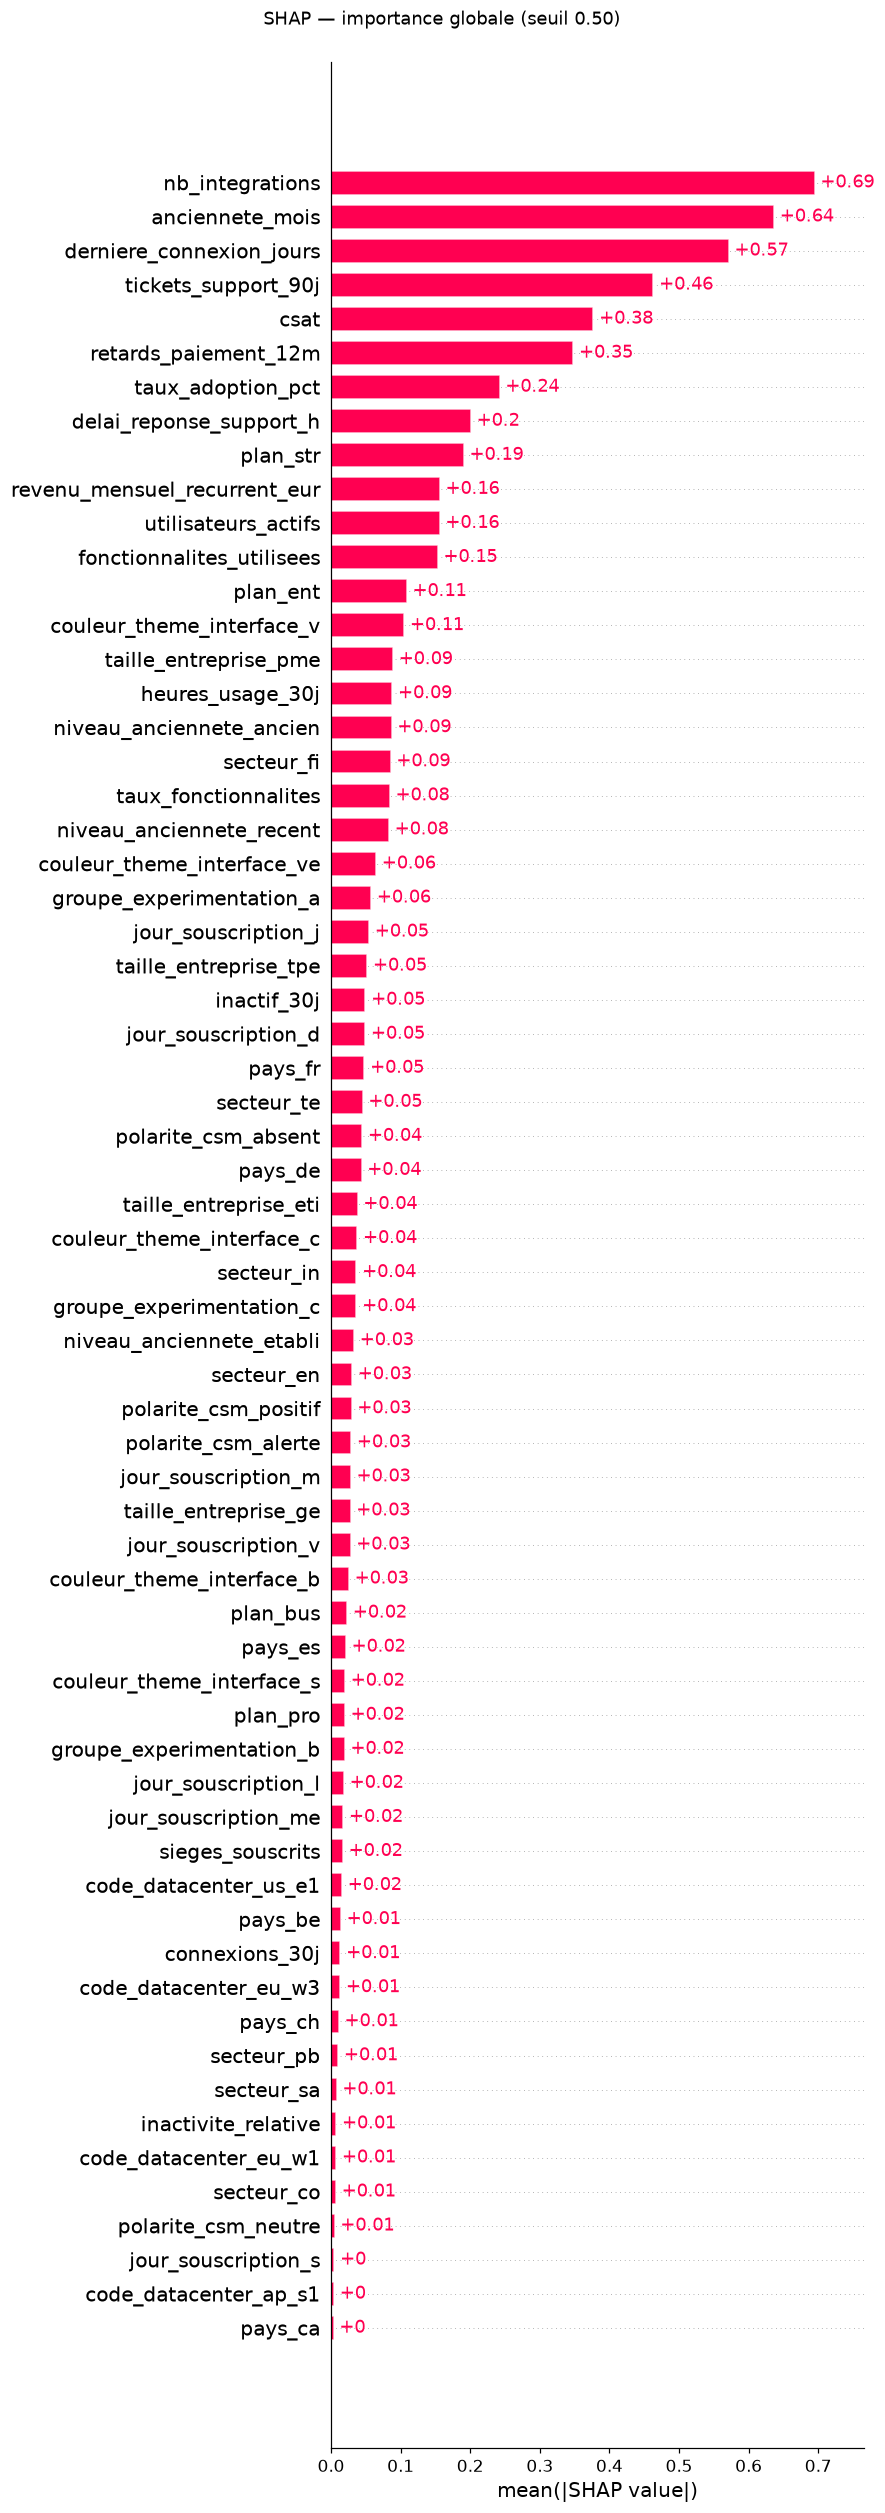

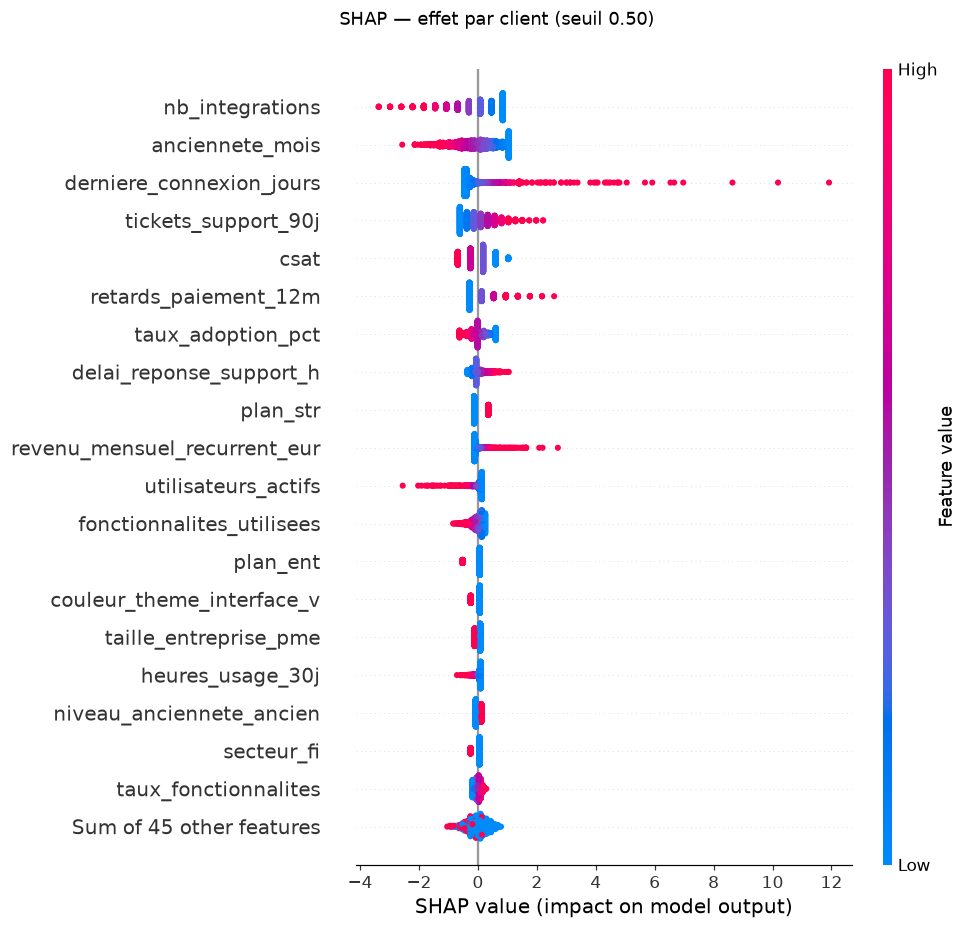

In [8]:
from ml_churn.training.classification.baseline.classification_baseline_training import (
    train_classification_baseline,
)
from ml_churn.training.common.explain import (
    display_figure,
    shap_bar_figure,
    shap_summary_figure,
)

SEUIL = resultat_tuning.seuil  # ou une valeur fixee a la main

resultat_baseline = train_classification_baseline(seuil=SEUIL)

# Explication sur le jeu de test : ce que le modele a appris se juge sur des
# lignes qu'il n'a pas vues. Les memes figures sont attachees aux runs MLflow
# par la recherche de seuil.
display_figure(
    shap_bar_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — importance globale (seuil {SEUIL:.2f})",
        max_features=None,  # toutes les colonnes, sans regroupement
    )
)
display_figure(
    shap_summary_figure(
        resultat_baseline.model,
        resultat_baseline.X_test,
        titre=f"SHAP — effet par client (seuil {SEUIL:.2f})",
    )
)